In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

In [1]:
import numpy as np
from boolean_analysis import calculate_fourier_transform_matrix, parity_of_1s
import pandas as pd
from tqdm import tqdm
import pickle
from boolean_fourier_learner import BooleanFourierLearner
from pathlib import Path
import lzma

%matplotlib inline

In [5]:
number_spins = 4
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6).astype("int64") * 2 - 1
for batch_size in range(1, len(x)):
    learner = BooleanFourierLearner(number_spins=number_spins)
    learner.fit(x, y, batch_size=batch_size, show_progress=False)
    assert (
        np.isclose(
            learner.coeffs_,
            np.array(
                [
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    1.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                ]
            ),
        )
    ).all()

In [6]:
number_spins = 4
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6).astype("int64") * 2 - 1
for batch_size in range(1, len(x)):
    learner = BooleanFourierLearner(
        number_spins=number_spins,
        subsets=np.array([0, 1, 6, 7, 8], dtype="uint64"),
    )
    learner.fit(x, y, batch_size=batch_size)
    assert (
        np.isclose(
            learner.coeffs_,
            np.array(
                [
                    0.0,
                    0.0,
                    1.0,
                    0.0,
                    0.0,
                ]
            ),
        )
    ).all()

In [7]:
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6).astype("int64") * 2 - 1
learner = BooleanFourierLearner(number_spins=number_spins)
learner.fit(
    x, y, batch_size=2, stochastic_iterations=1000, show_progress=False
)
assert abs(learner.coeffs_[6] - 1) < 1e-5
assert (
    np.max(np.abs(learner.coeffs_[np.arange(len(learner.coeffs_)) != 6])) < 0.1
)

In [6]:
number_spins = 10
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6, n=number_spins).astype("int64") * 2 - 1
learner = BooleanFourierLearner(number_spins=number_spins)
learner.fit(
    x,
    y,
    batch_size=200,
    stochastic_iterations=10,
    pickle_progress_to="test-experiment/{i}.pickle",
)

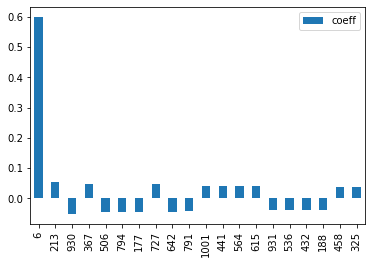

In [7]:
with lzma.open("test-experiment/5.pickle") as f:
    pickle.load(f).get_coeffs_df().iloc[:20].plot.bar()

<AxesSubplot: >

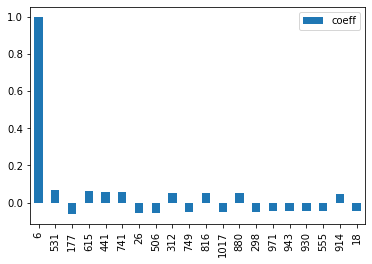

In [8]:
learner.get_coeffs_df().iloc[:20].plot.bar()

In [9]:
# Long test

# number_spins = 24
# x = np.arange(2**number_spins, dtype="uint64")
# x = x[
#     ((x.reshape(-1, 1) >> np.arange(number_spins, dtype="uint64")) & 1).sum(
#         axis=1
#     )
#     == number_spins // 2
# ]
# y = parity_of_1s(x & 17, n=number_spins).astype("int64") * 2 - 1
# learner = BooleanFourierLearner(number_spins=number_spins)
# learner.fit(x, y, batch_size=50, stochastic_iterations=10)
# learner.get_coeffs_df().iloc[:20].plot.bar()
# learner.get_coeffs_df().iloc[2:]["coeff"].max()